In [2]:
import pandas as pd

In [12]:
data = {
    'study_hours': [1, 2, 3, 1, 4, 5, 3, 6, 7, 2,
                    8, 5, 6, 7, 3, 8, 9, 10, 4, 7,
                    6, 9, 10, 8, 5],
    'attendance_rate': [50, 55, 60, 40, 65, 70, 55, 75, 80, 50,
                        85, 72, 78, 82, 60, 88, 90, 95, 65, 79,
                        77, 93, 99, 89, 71],
    'pass_exam': [0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
                  1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
                  1, 1, 1, 1, 1]
}


df = pd.DataFrame(data)
df.head()

,study_hours,attendance_rate,pass_exam
0,1,50,0
1,2,55,0
2,3,60,0
3,1,40,0
4,4,65,0


# Output value

In [28]:
y= df['pass_exam']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: pass_exam, dtype: int64

# Input value

In [36]:
x=df.drop('pass_exam',axis=1)
x.head()

,study_hours,attendance_rate
0,1,50
1,2,55
2,3,60
3,1,40
4,4,65


# Model training using Logistic Regression

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [39]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [46]:
y_test

8     1
16    1
0     0
23    1
11    1
Name: pass_exam, dtype: int64

In [47]:
y_pred= lr.predict(x_test)
y_pred

array([1, 1, 0, 1, 1])

In [48]:
lr.predict_proba(x_test)

array([[5.87502876e-04, 9.99412497e-01],
       [2.40705821e-07, 9.99999759e-01],
       [9.99999883e-01, 1.16788252e-07],
       [5.55001097e-07, 9.99999445e-01],
       [2.36699921e-01, 7.63300079e-01]])

# Accuracy

In [49]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

1.0

In [50]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

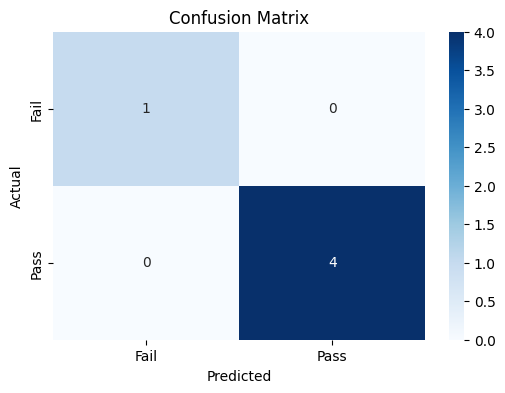

In [51]:
# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 7. Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()